In [2]:
import gdelt

gd = gdelt.gdelt()

events_all = gd.Search(['2025 November 24'],table='events',output='gpd',normcols=True, coverage=True) 
print(events_all.shape)
events_ua = events_all[(events_all.actiongeocountrycode == 'UP')] 
print(events_ua.shape)
events_ua.head()

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

(114862, 63)
(4649, 63)


,globaleventid,sqldate,monthyear,year,fractiondate,actor1code,actor1name,actor1countrycode,actor1knowngroupcode,actor1ethniccode,...,actiongeofullname,actiongeocountrycode,actiongeoadm1code,actiongeoadm2code,actiongeolat,actiongeolong,actiongeofeatureid,dateadded,sourceurl,geometry
38,1275787068,20251124,202511,2025,2025.8877,NaN,NaN,NaN,NaN,NaN,...,"Kyiv, Kyyiv, Misto, Ukraine",UP,UP12,28554,50.4333,30.5167,-1044367,20251124021500,https://www.ksl.com:443/article/51409422/us-ha...,POINT (30.5167 50.4333)
39,1275787069,20251124,202511,2025,2025.8877,NaN,NaN,NaN,NaN,NaN,...,"Kyiv, Kyyiv, Misto, Ukraine",UP,UP12,28554,50.4333,30.5167,-1044367,20251124021500,https://www.ksl.com:443/article/51409422/us-ha...,POINT (30.5167 50.4333)
170,1275787200,20251124,202511,2025,2025.8877,CHE,GENEVA,CHE,NaN,NaN,...,"Kyiv, Kyyiv, Misto, Ukraine",UP,UP12,28554,50.4333,30.5167,-1044367,20251124021500,https://www.ksl.com:443/article/51409422/us-ha...,POINT (30.5167 50.4333)
171,1275787201,20251124,202511,2025,2025.8877,CHE,SWITZERLAND,CHE,NaN,NaN,...,"Kyiv, Kyyiv, Misto, Ukraine",UP,UP12,28554,50.4333,30.5167,-1044367,20251124021500,https://www.asiaone.com:443/world/us-ukraine-s...,POINT (30.5167 50.4333)
173,1275787203,20251124,202511,2025,2025.8877,CHE,GENEVA,CHE,NaN,NaN,...,"Kyiv, Kyyiv, Misto, Ukraine",UP,UP12,28554,50.4333,30.5167,-1044367,20251124021500,https://fortune.com/2025/11/23/secret-us-russi...,POINT (30.5167 50.4333)


Find domain names as a proxy for country of origin:

In [73]:
# First: Define a helper function to find the third slash in a domain (first two after https: or http:)
def find_nth(haystack: str, needle: str, n: int) -> int:
    start = haystack.find(needle)
    while start >= 0 and n > 1:
        start = haystack.find(needle, start+len(needle))
        n -= 1
    return start

def find_domain_ua(url: str) -> str:
    third_slash_index = find_nth(url, "/", 3)
    domain_before_substring = url[:third_slash_index]
    domain_before_substring = domain_before_substring.strip(":443") # Common PORT variable
    dot_index = domain_before_substring[::-1].find(".") # First dot from the end
    domain_name = domain_before_substring[-(dot_index+1):] # Extract domain name
    return domain_name

events_ua["country_domain"] = events_ua.sourceurl.apply(find_domain_ua) # Apply the function to extract domain names
events_ua.country_domain.value_counts().head(10)

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


country_domain
.com    2936
.uk      359
.org     305
.ua      106
.gr       98
.cn       85
.au       83
.ie       82
.tr       77
.az       76
Name: count, dtype: int64

## Next Step: V4 Ukraine News Dataset

Basic idea: Aggregate news from 2014 to 2025, with the following fields:
- **date**: DATE format, dates picked at semi-regular intervals in the given years
- **tot_events_count**: Total count of all news events on that given date
- **ua_events_count**: Count of events related to Ukraine
- **ua_events_ua**: Count of events related to Ukraine from .ua domains
- **ua_events_pl**: Count of events related to Ukraine from .pl domains
- **ua_events_cz**: Count of events related to Ukraine from .cz domains
- **ua_events_sk**: Count of events related to Ukraine from .sk domains
- **ua_events_hu**: Count of events related to Ukraine from .hu domains

In [78]:
# Step 1: Define more general function to find UA news for a given date
def find_ua_news_for_date(date: str):
    gd =  gdelt.gdelt()
    events_all = gd.Search([date],table='events',output='gpd',normcols=True, coverage=True) # Find all events
    events_ua = events_all[(events_all.actiongeocountrycode == 'UP')] # Find UA-related events
    events_ua["country_domain"] = events_ua.sourceurl.apply(find_domain_ua) # Extract domain names
    
    return_dict = {"date": date,
                   "tot_events_count": events_all.shape[0],
                   "ua_events_count": events_ua.shape[0],
                   "ua_events_ua": events_ua[events_ua.country_domain==".ua"].shape[0],
                   "ua_events_pl": events_ua[events_ua.country_domain==".pl"].shape[0],
                   "ua_events_cz": events_ua[events_ua.country_domain==".cz"].shape[0],
                   "ua_events_sk": events_ua[events_ua.country_domain==".sk"].shape[0],
                   "ua_events_hu": events_ua[events_ua.country_domain==".hu"].shape[0],}
    
    return return_dict

In [80]:
yesterday_stats = find_ua_news_for_date('2025 December 6')
yesterday_stats

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

{'date': '2025 December 6',
 'tot_events_count': 70178,
 'ua_events_count': 1638,
 'ua_events_ua': 33,
 'ua_events_pl': 0,
 'ua_events_cz': 4,
 'ua_events_sk': 0,
 'ua_events_hu': 0}

In [93]:
november_stats = find_ua_news_for_date('2025 November 24')
november_stats

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

{'date': '2025 November 24',
 'tot_events_count': 114862,
 'ua_events_count': 4649,
 'ua_events_ua': 106,
 'ua_events_pl': 4,
 'ua_events_cz': 5,
 'ua_events_sk': 4,
 'ua_events_hu': 8}

Next step: Automate with semi-randomly picked dates (and **error handling** in case of max retries), then store in big DF

In [110]:
import pandas as pd
from datetime import datetime 

def combine_ua_stats_for_dates(date_list):
    stats_list = []
    for date in date_list:
        stats = find_ua_news_for_date(date)
        stats_list.append(stats)
    df = pd.DataFrame(stats_list)

    # Last step: Convert date strings to datetime objects
    df['date'] = pd.to_datetime(df['date'], format='%Y %B %d').dt.date
    return df

combined_stats = combine_ua_stats_for_dates(['2025 November 24', '2025 December 6'])
combined_stats

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

,date,tot_events_count,ua_events_count,ua_events_ua,ua_events_pl,ua_events_cz,ua_events_sk,ua_events_hu
0,2025-11-24,114862,4649,106,4,5,4,8
1,2025-12-06,70178,1638,33,0,4,0,0


In [115]:
# Here: Programatically define range (with steps of days) the dataset will be aggregated upon
    # Build in error handling to provision for a timeout in case of overloading GDELT API
    # ... and aggregate dates from January 1st, 2014 to November 30th, 2025
    # Wished interval: Step 10 days

from datetime import timedelta
def generate_date_range(start_date: str, end_date: str, step_days: int):
    start_dt = datetime.strptime(start_date, '%Y %B %d')
    end_dt = datetime.strptime(end_date, '%Y %B %d')
    
    date_list = []
    current_dt = start_dt
    while current_dt <= end_dt:
        date_list.append(current_dt.strftime('%Y %B %d'))
        current_dt += timedelta(days=step_days)
    
    return date_list

# date_range = generate_date_range('2014 January 1', '2025 November 30', 10)
    # Reason: GDELT 2.0 only supports February 18th, 2015 onwards
date_range = generate_date_range('2015 February 18', '2025 November 30', 10)

In [117]:
def combine_stats_for_date_range(date_range): # Now with error handling...
    stats_list = []
    for date in date_range:
        try:
            stats = find_ua_news_for_date(date)
            stats_list.append(stats)
        except Exception as e:
            print(f"Error processing date {date}: {e}")
    df = pd.DataFrame(stats_list)

    # Convert date strings to datetime objects
    df['date'] = pd.to_datetime(df['date'], format='%Y %B %d').dt.date
    return df

In [119]:
date_range = generate_date_range('2015 February 18', '2015 March 31', 10)
date_df = combine_stats_for_date_range(date_range)
date_df

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

,date,tot_events_count,ua_events_count,ua_events_ua,ua_events_pl,ua_events_cz,ua_events_sk,ua_events_hu
0,2015-02-18,17896,262,0,0,0,0,0
1,2015-02-28,127827,1947,28,1,0,0,0
2,2015-03-10,206813,1758,39,0,0,0,0
3,2015-03-20,204582,2108,131,0,0,0,0
4,2015-03-30,194287,1096,72,0,1,1,0


In [120]:
import time

date_range = generate_date_range('2021 November 30', '2025 November 30', 10)

def combine_stats_for_date_range(date_range, max_retries=3, initial_timeout=30, max_timeout=120):
    """
    Combine stats for a date range with timeout and retry handling.
    
    Args:
        date_range: List of date strings to process
        max_retries: Maximum number of retry attempts per date
        initial_timeout: Initial wait time between retries (seconds)
        max_timeout: Maximum wait time between retries (seconds)
    """
    stats_list = []
    
    for date in date_range:
        success = False
        retries = 0
        
        while not success and retries < max_retries:
            try:
                stats = find_ua_news_for_date(date)
                stats_list.append(stats)
                success = True
                print(f"Successfully processed date: {date}")
                
            except Exception as e:
                retries += 1
                if retries < max_retries:
                    # Exponential backoff with max cap
                    wait_time = min(initial_timeout * (2 ** (retries - 1)), max_timeout)
                    print(f"Error processing date {date}: {e}")
                    print(f"Retrying in {wait_time} seconds... (Attempt {retries}/{max_retries})")
                    time.sleep(wait_time)
                else:
                    print(f"Failed to process date {date} after {max_retries} attempts: {e}")
                    # Add a row with None values to maintain date continuity
                    stats_list.append({
                        "date": date,
                        "tot_events_count": None,
                        "ua_events_count": None,
                        "ua_events_ua": None,
                        "ua_events_pl": None,
                        "ua_events_cz": None,
                        "ua_events_sk": None,
                        "ua_events_hu": None
                    })
    
    df = pd.DataFrame(stats_list)
    
    # Convert date strings to datetime objects
    df['date'] = pd.to_datetime(df['date'], format='%Y %B %d').dt.date
    return df

date_df = combine_stats_for_date_range(date_range)
date_df

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

Successfully processed date: 2021 November 30


C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

Successfully processed date: 2021 December 10


C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

...

C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

Successfully processed date: 2025 November 19


C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\I745534\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyproj\crs\crs.py:143: FutureWarning

Successfully processed date: 2025 November 29


,date,tot_events_count,ua_events_count,ua_events_ua,ua_events_pl,ua_events_cz,ua_events_sk,ua_events_hu
0,2021-11-30,117917.0,974.0,29.0,0.0,0.0,0.0,0.0
1,2021-12-10,117253.0,1723.0,17.0,0.0,0.0,0.0,0.0
2,2021-12-20,91915.0,795.0,15.0,0.0,0.0,0.0,0.0
3,2021-12-30,87870.0,1018.0,24.0,0.0,0.0,0.0,0.0
4,2022-01-09,56459.0,654.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
142,2025-10-20,111586.0,3454.0,99.0,1.0,0.0,13.0,14.0
143,2025-10-30,137801.0,1538.0,51.0,0.0,0.0,0.0,0.0
144,2025-11-09,66159.0,874.0,0.0,1.0,3.0,0.0,0.0
145,2025-11-19,132288.0,3131.0,102.0,2.0,3.0,6.0,3.0


<Axes: title={'center': 'UA-related News Events Over Time'}, xlabel='date'>

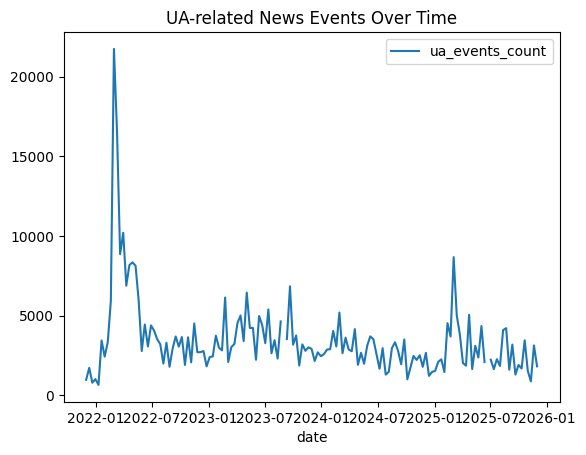

In [124]:
date_df.plot(x='date', y=['ua_events_count'], kind='line', title='UA-related News Events Over Time')

<Axes: title={'center': 'UA-related News Events as Percentage of All News Events Over Time'}, xlabel='date'>

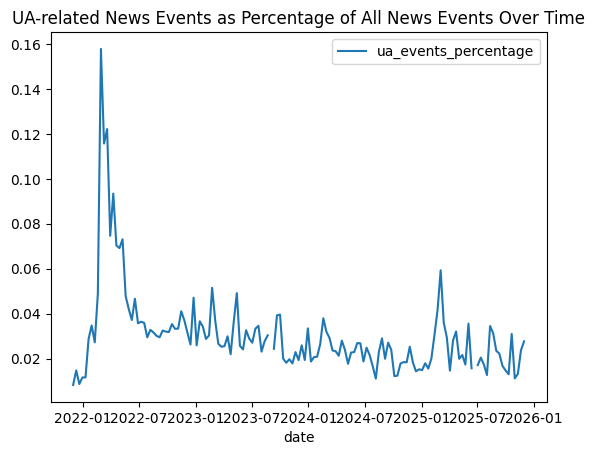

In [ ]:
## UA-related events as percentage of all news events
date_df["ua_events_percentage"] = (date_df["ua_events_count"] / date_df["tot_events_count"])
date_df.plot(x='date', y=['ua_events_percentage'], kind='line', title='UA-related News Events as Percentage of All News Events Over Time') 

<Axes: title={'center': 'UA-related News Events in Poland Over Time'}, xlabel='date'>

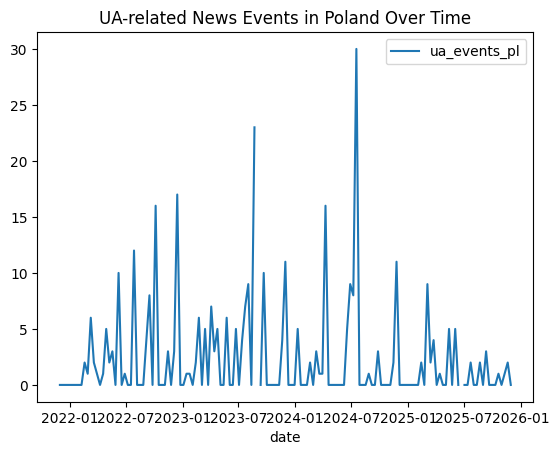

In [127]:
date_df.plot(x='date', y=['ua_events_pl'], kind='line', title='UA-related News Events in Poland Over Time')

<Axes: title={'center': 'UA-related News Events in Czech Republic Over Time'}, xlabel='date'>

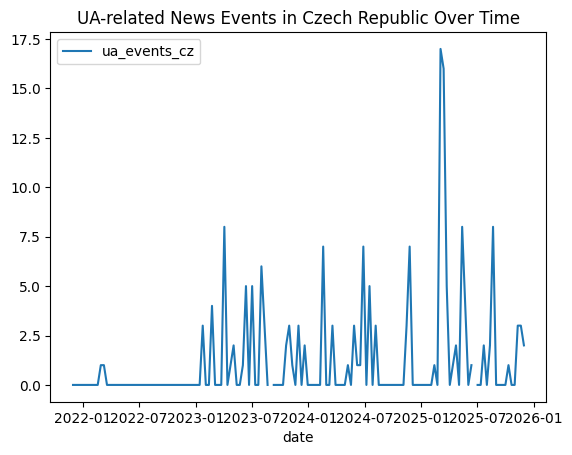

In [128]:
date_df.plot(x='date', y=['ua_events_cz'], kind='line', title='UA-related News Events in Czech Republic Over Time')

<Axes: title={'center': 'UA-related News Events in Slovakia Over Time'}, xlabel='date'>

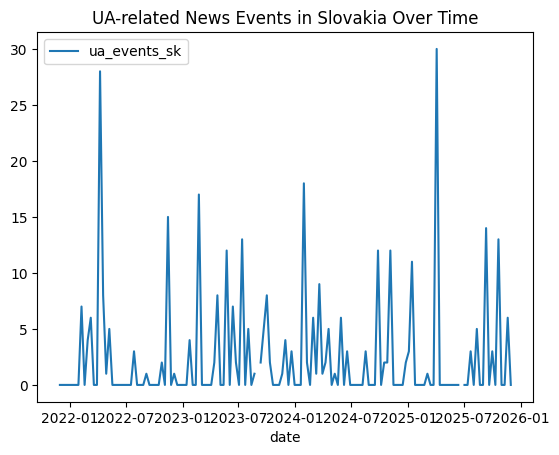

In [129]:
date_df.plot(x='date', y=['ua_events_sk'], kind='line', title='UA-related News Events in Slovakia Over Time')

<Axes: title={'center': 'UA-related News Events in Hungary Over Time'}, xlabel='date'>

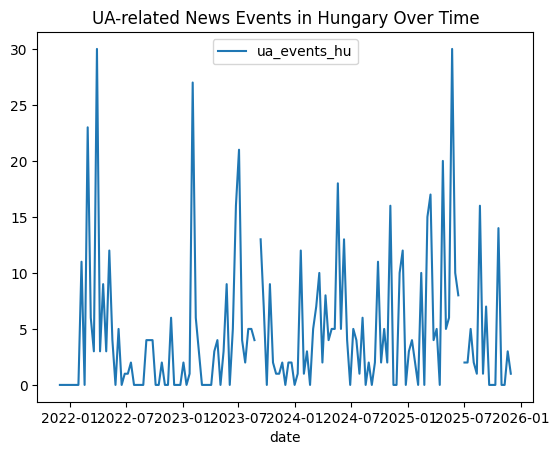

In [130]:
date_df.plot(x='date', y=['ua_events_hu'], kind='line', title='UA-related News Events in Hungary Over Time')